# Sequential Convex Programming for Trajectory Generation

### Libraries

In [17]:
%load_ext autoreload
%autoreload 2

from jax import config
config.update("jax_enable_x64", True)

import os
import copy
import pickle
import warnings
import numpy as np
from cvxpygen import cpg
import matplotlib.pyplot as plt


from mpc import RUN
from scp import prox_convex
from cvx import parse_convex_problem
from disc import jit_int_mult_fcn, jit_cal_disc_fcn
from jitting import jit_ncvx_dt_fcn_grad, jit_ncvx_ct_fcn_grad, jit_ncvx_cvx_fcn_grad, jit_ncvx_smth_fcn_grad, jit_ncvx_comp_fcn_grad

from utils import profile_with_cprofile, make_anim

from model.di_until.dynamics import dynamics
from model.di_until.params import params_fcn, scale_params, unscale_prox_results
from model.di_until.cost_cons import cvx_cost_fcn, cvx_cons_fcn, ncvx_dt_fcn, ncvx_ct_fcn, ncvx_cvx_fcn, ncvx_cvx_cp_fcn, ncvx_smth_fcn, ncvx_comp_fcn
from model.di_until.plot import plot_trajectory_3d_speed, plot_speed_profile, plot_station_margin

warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Parameters

In [18]:
K = 5 # Total number of nodes
t_f = 10.7649 # Total simulation time [s] spd = 1

free_final_time = False
time_dil = False

params = params_fcn(t_f, K, free_final_time, time_dil)

params_sc = scale_params(copy.deepcopy(params))
params_sc = dynamics(copy.deepcopy(params_sc))

### Call functions

In [19]:
fcn_dict = {}

fcn_dict['cvx_cost_fcn'] = cvx_cost_fcn
fcn_dict['cvx_cons_fcn'] = cvx_cons_fcn

In [20]:
fcn_dict['cal_disc_jitted'] = jit_cal_disc_fcn(params_sc)
fcn_dict['int_mult_jitted'] = jit_int_mult_fcn(params_sc)

In [21]:
fcn_dict['ncvx_dt_fcn_jitted'], fcn_dict['ncvx_dt_fcn_grad_jitted'] = jit_ncvx_dt_fcn_grad(ncvx_dt_fcn, params_sc)
fcn_dict['ncvx_ct_fcn_jitted'], fcn_dict['ncvx_ct_fcn_grad_jitted'] = jit_ncvx_ct_fcn_grad(ncvx_ct_fcn, params_sc)

In [22]:
# -------------------------------------------
# --------------- prox-convex ---------------
# -------------------------------------------
fcn_dict['ncvx_cvx_fcn'] = ncvx_cvx_fcn
fcn_dict['ncvx_cvx_cp_fcn'] = ncvx_cvx_cp_fcn

fcn_dict['ncvx_cvx_fcn_jitted'], fcn_dict['ncvx_cvx_fcn_grad_jitted'] = jit_ncvx_cvx_fcn_grad(ncvx_cvx_fcn, params_sc)
fcn_dict['ncvx_smth_fcn_jitted'], fcn_dict['ncvx_smth_fcn_grad_jitted'] = jit_ncvx_smth_fcn_grad(ncvx_smth_fcn, params_sc)
fcn_dict['ncvx_comp_fcn_jitted'], fcn_dict['ncvx_comp_fcn_grad_jitted'] = jit_ncvx_comp_fcn_grad(ncvx_comp_fcn, params_sc)
# -------------------------------------------
# --------------- prox-convex ---------------
# -------------------------------------------

### Code generation

In [23]:
if not(params['use_generated_code']) or params['generate_code']:
    # Parse problem if you are not using the generated code
    cvx_prb = parse_convex_problem(params_sc, fcn_dict)

In [ ]:
if params['generate_code']:
    # Generate code
    code_dir = "di_until_solver"
    !rm -rf di_until_solver/*
    os.makedirs(code_dir, exist_ok=True)  # <- This ensures the directory exists
    cpg.generate_code(cvx_prb, solver = params['convex_solver'], wrapper=True, code_dir=code_dir)

In [25]:
if params['use_generated_code']:
    # Use generated code
    with open('di_until_solver/problem.pickle', 'rb') as f:
        cvx_prb = pickle.load(f)      

    from di_until_solver.cpg_solver import cpg_solve
    cvx_prb.register_solve('CPG', cpg_solve)

### Prox-convex

In [26]:
prox_results_sc = prox_convex(  copy.deepcopy(params_sc), 
                                cvx_prb,
                                fcn_dict,
                                )

Ite                 T-Ite               T-Disc              T-SubP              T-J_Np              dyn_cost            ctc_cost            none                until_pos_spd       eventually_visit    ptr_cost            lcd                 nlcd                lc                  nlc                 D-NL                D-L                 Rho                 W-TR                Note                Staus               
0                   0                   0                   0                   0                   4000.0              0.0                 0.0                 78.6485             0.0                 0.0                 0.0                 4000.0              0.0                 4078.6485           0                   0                   0                   1.0                 Start               Start               
1                   0.0093              0.0002              0.0011              0.0044              0.0                 0.0                 0.0               

In [27]:
print('Total iteration      time:', round(sum(prox_results_sc['T-Ite'])*1e3, 3), 'ms')
print('Total discretization time:', round(sum(prox_results_sc['T-Disc'])*1e3, 3), 'ms')
print('Total subproblem     time:', round(sum(prox_results_sc['T-SubP'])*1e3, 3), 'ms')
print('Total Jax to Numpy   time:', round(sum(prox_results_sc['T-J_Np'])*1e3, 3), 'ms')

print('\n')

tot_ds = sum(prox_results_sc['T-Disc']) + sum(prox_results_sc['T-SubP'])
print('Total disc-subp      time:', round(tot_ds*1e3, 3), 'ms')
tot_dsj = sum(prox_results_sc['T-Disc']) + sum(prox_results_sc['T-SubP']) + sum(prox_results_sc['T-J_Np'])
print('Total disc-subp-j_np time:', round(tot_dsj*1e3, 3), 'ms')
print('Total others         time:', round((sum(prox_results_sc['T-Ite']) - tot_dsj)*1e3, 3), 'ms')

print('\n')

print('Flight time:', round(prox_results_sc['S_new'].sum(), 3))

Total iteration      time: 113.028 ms
Total discretization time: 0.686 ms
Total subproblem     time: 16.283 ms
Total Jax to Numpy   time: 21.624 ms


Total disc-subp      time: 16.969 ms
Total disc-subp-j_np time: 38.594 ms
Total others         time: 74.435 ms


Flight time: 0.0


### Dump results

In [28]:
# with open('prox_results_sc.pickle', 'wb') as out_f:
#     out_f.write(pickle.dumps(prox_results_sc))

In [29]:
# with open('prox_results_sc.pickle', 'rb') as f:
#     prox_results_sc = pickle.load(f)      

In [30]:
# with open('results.pickle', 'wb') as out_f:
#     out_f.write(pickle.dumps(results))
    
# with open('params.pickle', 'wb') as out_f:
#     out_f.write(pickle.dumps(params))

### Simulate

In [31]:
prox_results = unscale_prox_results(copy.deepcopy(prox_results_sc), params)

params = dynamics(copy.deepcopy(params))

results = RUN(copy.deepcopy(prox_results), 
                 copy.deepcopy(params))

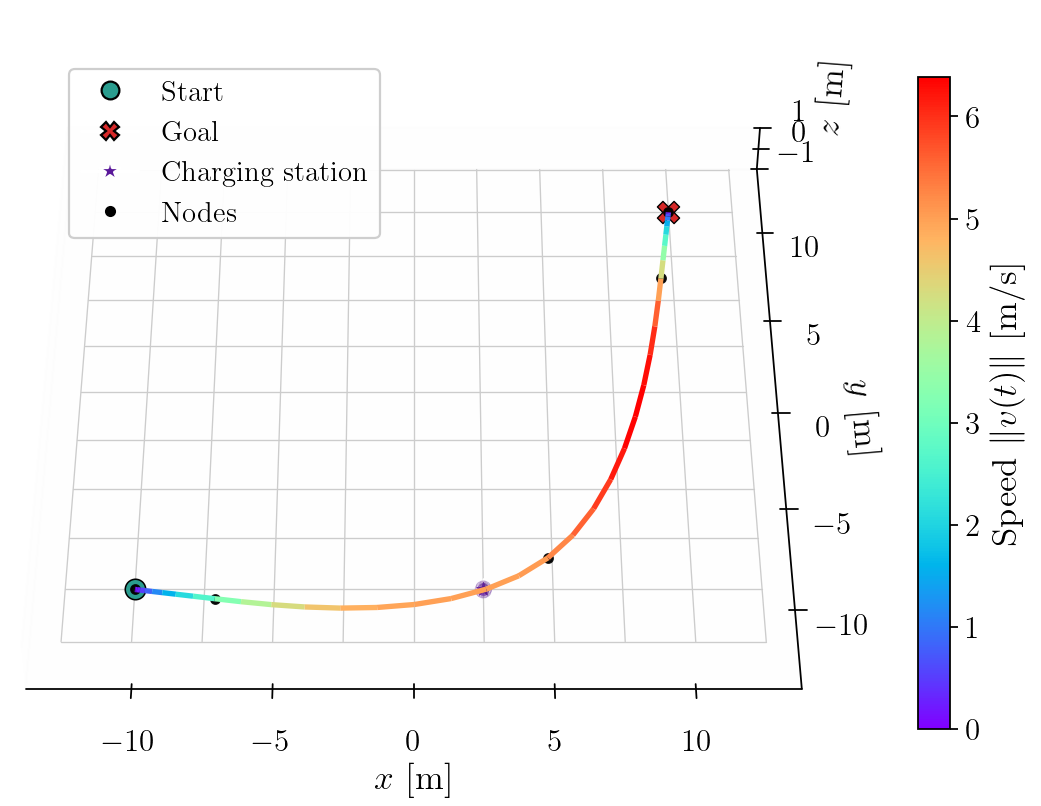

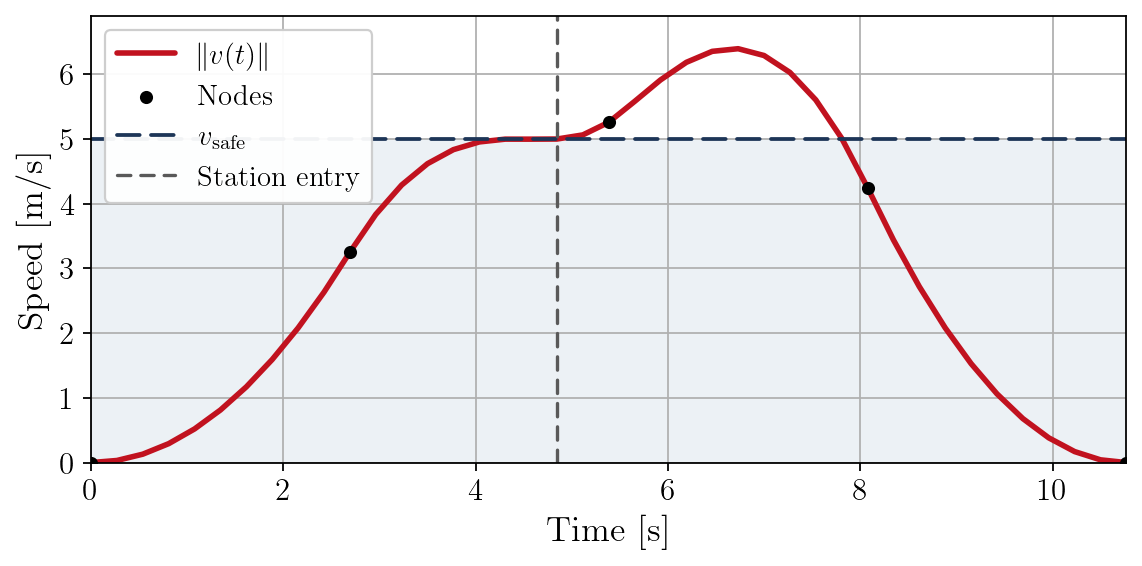

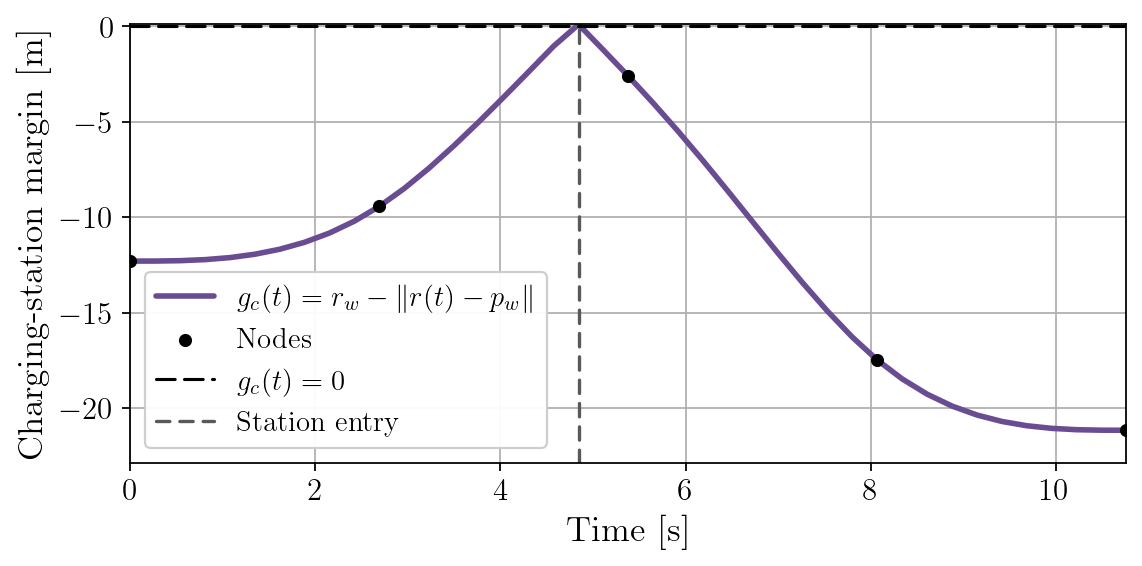

In [32]:
plot_trajectory_3d_speed(results, 
                         params, 
                         station_scale_for_display=1.5, 
                         min_display_radius=0.1, 
                         save_dir="Figures/CDC",
                         )
plot_speed_profile(results, params, save_dir="Figures/CDC")
plot_station_margin(results, params, save_dir="Figures/CDC")